# Imports + Dataframe Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from sksurv.ensemble import RandomSurvivalForest
from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "raw" / "metabric_clinical_data.tsv"

df_raw = pd.read_csv(DATA_PATH, sep="\t")

TIME_COL = "Overall Survival (Months)"
STATUS_COL = "Overall Survival Status"

# Clean time
df_raw[TIME_COL] = (
    df_raw[TIME_COL]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df_raw[TIME_COL] = pd.to_numeric(df_raw[TIME_COL], errors="coerce")

# Event mapping
s = df_raw[STATUS_COL].astype(str).str.upper()
df_raw["event"] = np.where(
    s.str.startswith("1:"), 1,
    np.where(s.str.startswith("0:"), 0, np.nan)
)

df = df_raw.dropna(subset=[TIME_COL, "event"]).copy()
df = df[df[TIME_COL] > 0]
df["event"] = df["event"].astype(bool)
df[TIME_COL] = df[TIME_COL].astype(float)

In [3]:
features = [
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Tumor Stage",
    "ER Status",
    "PR Status",
    "HER2 Status",
    "Chemotherapy",
    "Hormone Therapy",
    "Radio Therapy",
    "Neoplasm Histologic Grade",
]

In [4]:
X = df[features].copy()

# Numeric coercion
num_cols = [
    "Age at Diagnosis",
    "Tumor Size",
    "Lymph nodes examined positive",
    "Tumor Stage",
]
for c in num_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X = X.dropna()
y_df = df.loc[X.index, [TIME_COL, "event"]]

In [5]:
X = pd.get_dummies(X, drop_first=True)
y = Surv.from_arrays(
    event=y_df["event"].values,
    time=y_df[TIME_COL].values
)

# Train/Test Split (Stratified)

In [6]:
X_train, X_test, y_train_df, y_test_df = train_test_split(
    X,
    y_df,
    test_size=0.2,
    random_state=42,
    stratify=y_df["event"]
)

y_train = Surv.from_arrays(
    event=y_train_df["event"].values,
    time=y_train_df[TIME_COL].values
)
y_test = Surv.from_arrays(
    event=y_test_df["event"].values,
    time=y_test_df[TIME_COL].values
)

In [7]:
rsf = RandomSurvivalForest(
    n_estimators=500,
    min_samples_split=10,
    min_samples_leaf=15,
    max_features="sqrt",
    n_jobs=-1,
    random_state=42
)

rsf.fit(X_train, y_train)

,n_estimators,500
,max_depth,None
,min_samples_split,10
,min_samples_leaf,15
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,bootstrap,True
,oob_score,False
,n_jobs,-1
,random_state,42


In [11]:
risk_scores = rsf.predict(X_test)

cindex = concordance_index_censored(
    y_test["event"],
    y_test["time"],
    risk_scores
)[0]

print("RSF Test C-index:", round(cindex, 3))

RSF Test C-index: 0.7


In [10]:
import numpy as np
import pandas as pd
from sklearn.inspection import permutation_importance

# --- sample by POSITION, not by pandas index labels ---
n = min(500, len(X_test))
rng = np.random.default_rng(42)
pos = rng.choice(len(X_test), size=n, replace=False)

X_small = X_test.iloc[pos].copy()
y_small = y_test[pos]   # ✅ positional slice for structured array

perm = permutation_importance(
    rsf,
    X_small,
    y_small,
    scoring=cindex_scorer,
    n_repeats=10,
    random_state=42,
    n_jobs=1
)

importances = pd.Series(perm.importances_mean, index=X_small.columns).sort_values(ascending=False)
importances.head(15)

Age at Diagnosis                 0.069030
Lymph nodes examined positive    0.040174
Tumor Size                       0.030253
Tumor Stage                      0.005239
HER2 Status_Positive             0.002753
Neoplasm Histologic Grade        0.002565
Hormone Therapy_YES              0.001510
PR Status_Positive               0.001271
ER Status_Positive               0.000871
Chemotherapy_YES                 0.000344
Radio Therapy_YES               -0.001678
dtype: float64

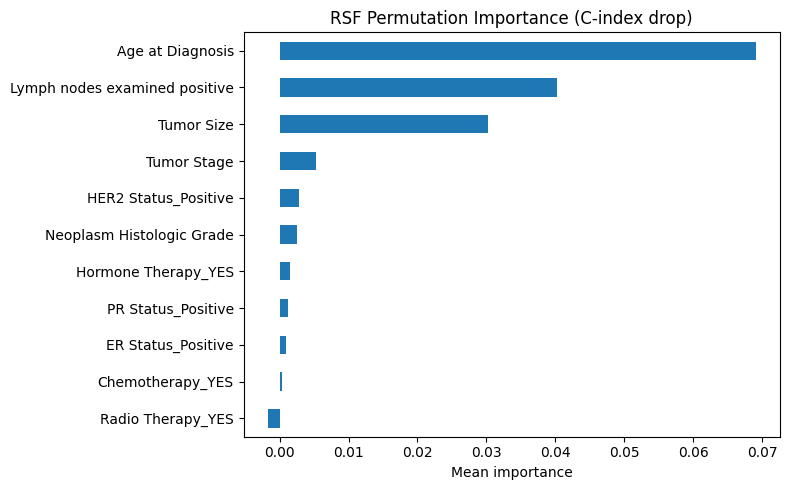

In [12]:
top = importances.head(15).sort_values()
plt.figure(figsize=(8,5))
top.plot(kind="barh")
plt.title("RSF Permutation Importance (C-index drop)")
plt.xlabel("Mean importance")
plt.tight_layout()
plt.show()